first zscore than mean and deviation lago and correlation matrix and bana kar corelation batao 

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [9]:
df=pd.read_csv("weather.csv")

In [10]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,NW,6.0,...,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6,Yes
1,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,W,4.0,...,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6,Yes
2,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,NNE,6.0,...,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8,Yes
3,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,30.0,...,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8,Yes
4,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,20.0,...,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0,No


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        366 non-null    float64
 1   MaxTemp        366 non-null    float64
 2   Rainfall       366 non-null    float64
 3   Evaporation    366 non-null    float64
 4   Sunshine       363 non-null    float64
 5   WindGustDir    363 non-null    object 
 6   WindGustSpeed  364 non-null    float64
 7   WindDir9am     335 non-null    object 
 8   WindDir3pm     365 non-null    object 
 9   WindSpeed9am   359 non-null    float64
 10  WindSpeed3pm   366 non-null    int64  
 11  Humidity9am    366 non-null    int64  
 12  Humidity3pm    366 non-null    int64  
 13  Pressure9am    366 non-null    float64
 14  Pressure3pm    366 non-null    float64
 15  Cloud9am       366 non-null    int64  
 16  Cloud3pm       366 non-null    int64  
 17  Temp9am        366 non-null    float64
 18  Temp3pm   

In [12]:
df.isnull().sum()

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          3
WindGustDir       3
WindGustSpeed     2
WindDir9am       31
WindDir3pm        1
WindSpeed9am      7
WindSpeed3pm      0
Humidity9am       0
Humidity3pm       0
Pressure9am       0
Pressure3pm       0
Cloud9am          0
Cloud3pm          0
Temp9am           0
Temp3pm           0
RainToday         0
RISK_MM           0
RainTomorrow      0
dtype: int64

In [13]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# fill numerical
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# fill categorical
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64


C:\Users\97abh\AppData\Local\Temp\ipykernel_19756\575848186.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\97abh\AppData\Local\Temp\ipykernel_19756\575848186.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [14]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0      8.0     24.3       0.0          3.4       6.3            7   
1     14.0     26.9       3.6          4.4       9.7            1   
2     13.7     23.4       3.6          5.8       3.3            7   
3     13.3     15.5      39.8          7.2       9.1            7   
4      7.6     16.1       2.8          5.6      10.6           10   

   WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0           30.0          12           7           6.0  ...           29   
1           39.0           0          13           4.0  ...           36   
2           85.0           3           5           6.0  ...           69   
3           54.0          14          13          30.0  ...           56   
4           50.0          10           2          20.0  ...           49   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1019.7       1015.0         7         7 

In [15]:
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

    MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0  0.122047  0.561221 -0.338485    -0.420844 -0.464807     0.157760   
1  1.119129  0.950363  0.514591    -0.045713  0.517159    -1.239178   
2  1.069275  0.426518  0.514591     0.479471 -1.331248     0.157760   
3  1.002802 -0.755874  9.092744     1.004655  0.343871     0.157760   
4  0.055575 -0.666072  0.325018     0.404445  0.777092     0.856229   

   WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  ...  Humidity9am  \
0      -0.756615    1.273177   -0.121658     -0.464339  ...    -0.307606   
1      -0.064635   -1.905784    1.200922     -0.718645  ...     0.607091   
2       3.472147   -1.111044   -0.562518     -0.464339  ...     0.759540   
3       1.088663    1.803004    1.200922      2.587333  ...    -0.764955   
4       0.781117    0.743350   -1.223808      1.315803  ...    -0.307606   

   Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm   Temp9am  \
0    -0.922225    -0.001350    -0.280220  

In [16]:
mean_values = X_scaled.mean()

print("Mean of each column:")
print(mean_values)

Mean of each column:
MinTemp         -3.106198e-16
MaxTemp          2.329648e-16
Rainfall         1.941374e-17
Evaporation      0.000000e+00
Sunshine        -1.941374e-17
WindGustDir     -7.765494e-17
WindGustSpeed   -1.844305e-16
WindDir9am       6.794808e-17
WindDir3pm       2.426717e-17
WindSpeed9am     1.261893e-16
WindSpeed3pm    -1.941374e-16
Humidity9am     -4.950503e-16
Humidity3pm     -6.794808e-17
Pressure9am     -2.135511e-14
Pressure3pm      1.186179e-14
Cloud9am        -9.706868e-18
Cloud3pm         1.164824e-16
Temp9am          3.882747e-17
Temp3pm          1.941374e-16
RainToday        3.882747e-17
RISK_MM          9.706868e-18
dtype: float64


In [17]:
z_scores = X_scaled.apply(zscore)

print(z_scores.head())

    MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustDir  \
0  0.122047  0.561221 -0.338485    -0.420844 -0.464807     0.157760   
1  1.119129  0.950363  0.514591    -0.045713  0.517159    -1.239178   
2  1.069275  0.426518  0.514591     0.479471 -1.331248     0.157760   
3  1.002802 -0.755874  9.092744     1.004655  0.343871     0.157760   
4  0.055575 -0.666072  0.325018     0.404445  0.777092     0.856229   

   WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  ...  Humidity9am  \
0      -0.756615    1.273177   -0.121658     -0.464339  ...    -0.307606   
1      -0.064635   -1.905784    1.200922     -0.718645  ...     0.607091   
2       3.472147   -1.111044   -0.562518     -0.464339  ...     0.759540   
3       1.088663    1.803004    1.200922      2.587333  ...    -0.764955   
4       0.781117    0.743350   -1.223808      1.315803  ...    -0.307606   

   Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm   Temp9am  \
0    -0.922225    -0.001350    -0.280220  

In [18]:
corr_matrix = df.corr()

print(corr_matrix)

                MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
MinTemp        1.000000  0.752471  0.201939     0.649930  0.035531   
MaxTemp        0.752471  1.000000 -0.073560     0.690026  0.451395   
Rainfall       0.201939 -0.073560  1.000000    -0.007293 -0.149326   
Evaporation    0.649930  0.690026 -0.007293     1.000000  0.316942   
Sunshine       0.035531  0.451395 -0.149326     0.316942  1.000000   
WindGustDir   -0.200508 -0.219727  0.017463    -0.177203 -0.041403   
WindGustSpeed  0.217224  0.109415  0.096160     0.287709  0.095676   
WindDir9am    -0.176774 -0.146104  0.002535    -0.193338 -0.032094   
WindDir3pm    -0.065350  0.018880  0.059179    -0.069996  0.148228   
WindSpeed9am   0.126251 -0.214649  0.218979     0.068176 -0.064200   
WindSpeed3pm  -0.065922 -0.167873  0.056008     0.048601  0.072494   
Humidity9am   -0.207897 -0.359602  0.150109    -0.519587 -0.497692   
Humidity3pm   -0.040709 -0.533327  0.289013    -0.391780 -0.755186   
Pressure9am   -0.501

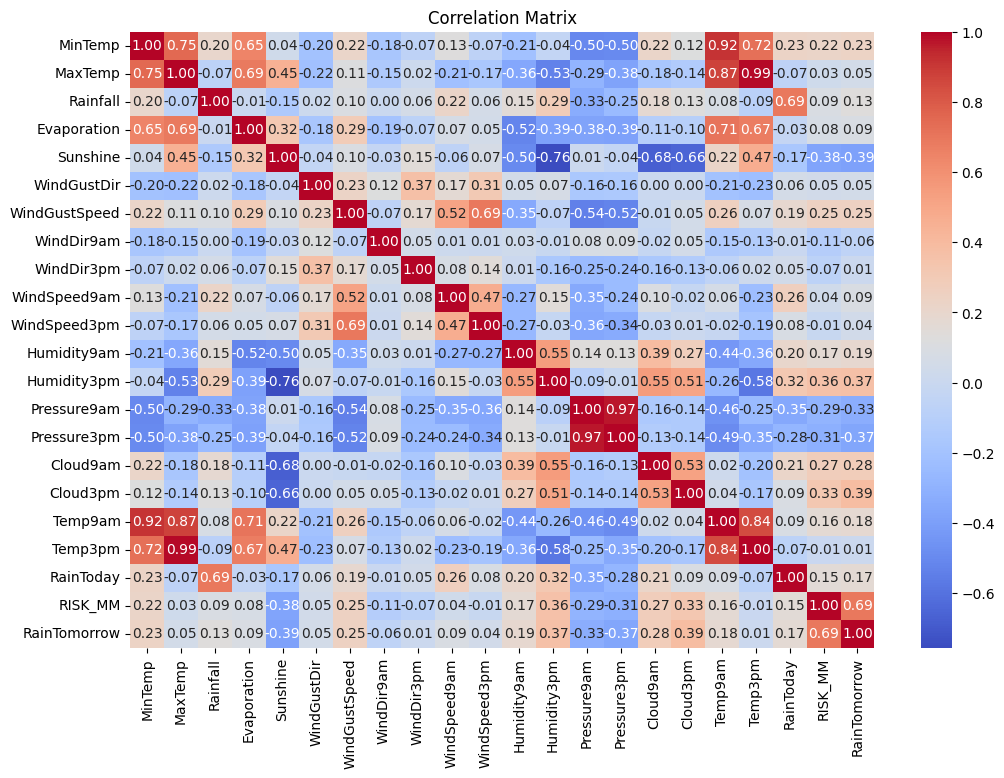

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [21]:
rain_corr = corr_matrix["RainTomorrow"].sort_values(ascending=False)
print(rain_corr)

RainTomorrow     1.000000
RISK_MM          0.693024
Cloud3pm         0.388020
Humidity3pm      0.366882
Cloud9am         0.284579
WindGustSpeed    0.249445
MinTemp          0.233213
Humidity9am      0.185077
Temp9am          0.182170
RainToday        0.168182
Rainfall         0.133586
Evaporation      0.090528
WindSpeed9am     0.088224
WindGustDir      0.050831
MaxTemp          0.049228
WindSpeed3pm     0.042505
Temp3pm          0.011105
WindDir3pm       0.007165
WindDir9am      -0.056109
Pressure9am     -0.330047
Pressure3pm     -0.370247
Sunshine        -0.386095
Name: RainTomorrow, dtype: float64


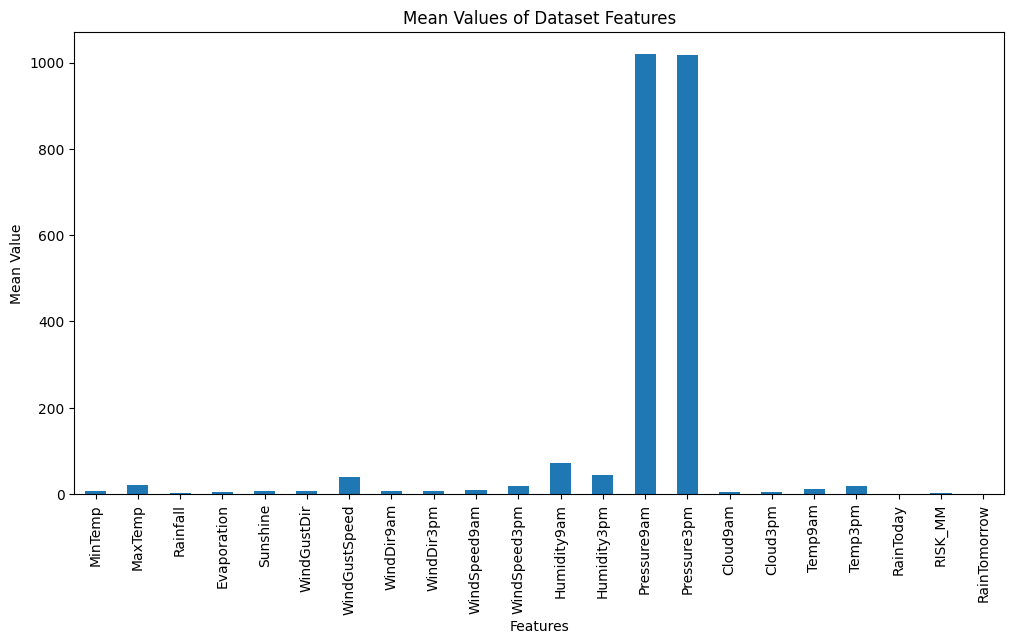

In [22]:
import matplotlib.pyplot as plt

mean_values = df.mean()

plt.figure(figsize=(12,6))
mean_values.plot(kind='bar')

plt.title("Mean Values of Dataset Features")
plt.xlabel("Features")
plt.ylabel("Mean Value")

plt.xticks(rotation=90)
plt.show()